In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("churn.csv")

df.head()

,Unnamed: 0,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,0,18,F,XW0DQ7H,Village,Platinum Membership,2017-08-17,No,xxxxxxxx,Gift Vouchers/Coupons,...,300.63,53005.25,17.0,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,1,32,F,5K0N3X1,City,Premium Membership,2017-08-28,?,CID21329,Gift Vouchers/Coupons,...,306.34,12838.38,10.0,NaN,Yes,No,Yes,Solved,Quality Customer Care,0
2,2,44,F,1F2TCL3,Town,No Membership,2016-11-11,Yes,CID12313,Gift Vouchers/Coupons,...,516.16,21027.00,22.0,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1
3,3,37,M,VJGJ33N,City,No Membership,2016-10-29,Yes,CID3793,Gift Vouchers/Coupons,...,53.27,25239.56,6.0,567.66,No,Yes,Yes,Unsolved,Poor Website,1
4,4,31,F,SVZXCWB,City,No Membership,2017-09-12,No,xxxxxxxx,Credit/Debit Card Offers,...,113.13,24483.66,16.0,663.06,No,Yes,Yes,Solved,Poor Website,1


In [3]:
df.shape

(36992, 24)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    36992 non-null  int64  
 1   age                           36992 non-null  int64  
 2   gender                        36992 non-null  object 
 3   security_no                   36992 non-null  object 
 4   region_category               31564 non-null  object 
 5   membership_category           36992 non-null  object 
 6   joining_date                  36992 non-null  object 
 7   joined_through_referral       36992 non-null  object 
 8   referral_id                   36992 non-null  object 
 9   preferred_offer_types         36704 non-null  object 
 10  medium_of_operation           36992 non-null  object 
 11  internet_option               36992 non-null  object 
 12  last_visit_time               36992 non-null  object 
 13  d

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    36992 non-null  int64  
 1   age                           36992 non-null  int64  
 2   gender                        36992 non-null  object 
 3   security_no                   36992 non-null  object 
 4   region_category               31564 non-null  object 
 5   membership_category           36992 non-null  object 
 6   joining_date                  36992 non-null  object 
 7   joined_through_referral       36992 non-null  object 
 8   referral_id                   36992 non-null  object 
 9   preferred_offer_types         36704 non-null  object 
 10  medium_of_operation           36992 non-null  object 
 11  internet_option               36992 non-null  object 
 12  last_visit_time               36992 non-null  object 
 13  d

In [6]:
df.isnull().sum()

Unnamed: 0                         0
age                                0
gender                             0
security_no                        0
region_category                 5428
membership_category                0
joining_date                       0
joined_through_referral            0
referral_id                        0
preferred_offer_types            288
medium_of_operation                0
internet_option                    0
last_visit_time                    0
days_since_last_login              0
avg_time_spent                     0
avg_transaction_value              0
avg_frequency_login_days           0
points_in_wallet                3443
used_special_discount              0
offer_application_preference       0
past_complaint                     0
complaint_status                   0
feedback                           0
churn_risk_score                   0
dtype: int64

In [7]:
df["region_category"] = df["region_category"].fillna(df["region_category"].mode()[0])

df["preferred_offer_types"] = df["preferred_offer_types"].fillna(df["preferred_offer_types"].mode()[0])

df["points_in_wallet"] = df["points_in_wallet"].fillna(df["points_in_wallet"].median())

In [8]:
df.dtypes

Unnamed: 0                        int64
age                               int64
gender                           object
security_no                      object
region_category                  object
membership_category              object
joining_date                     object
joined_through_referral          object
referral_id                      object
preferred_offer_types            object
medium_of_operation              object
internet_option                  object
last_visit_time                  object
days_since_last_login             int64
avg_time_spent                  float64
avg_transaction_value           float64
avg_frequency_login_days         object
points_in_wallet                float64
used_special_discount            object
offer_application_preference     object
past_complaint                   object
complaint_status                 object
feedback                         object
churn_risk_score                  int64
dtype: object

In [9]:
df.isnull().sum()

Unnamed: 0                      0
age                             0
gender                          0
security_no                     0
region_category                 0
membership_category             0
joining_date                    0
joined_through_referral         0
referral_id                     0
preferred_offer_types           0
medium_of_operation             0
internet_option                 0
last_visit_time                 0
days_since_last_login           0
avg_time_spent                  0
avg_transaction_value           0
avg_frequency_login_days        0
points_in_wallet                0
used_special_discount           0
offer_application_preference    0
past_complaint                  0
complaint_status                0
feedback                        0
churn_risk_score                0
dtype: int64

In [10]:
df.drop_duplicates(inplace=True)

df.shape

(36992, 24)

In [11]:
df["joining_date"] = pd.to_datetime(df["joining_date"])

df["joining_year"] = df["joining_date"].dt.year

df["joining_month"] = df["joining_date"].dt.month

df["joining_day"] = df["joining_date"].dt.day

In [12]:
df.describe()

,Unnamed: 0,age,joining_date,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score,joining_year,joining_month,joining_day
count,36992.000000,36992.000000,36992,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.00000,36992.000000
mean,18495.500000,37.118161,2016-07-04 04:57:59.325259520,-41.915576,243.472334,29271.194003,687.881611,0.540982,2016.006569,6.53344,15.687122
min,0.000000,10.000000,2015-01-01 00:00:00,-999.000000,-2814.109110,800.460000,-760.661236,0.000000,2015.000000,1.00000,1.000000
25%,9247.750000,23.000000,2015-10-01 00:00:00,8.000000,60.102500,14177.540000,624.350000,0.000000,2015.000000,4.00000,8.000000
50%,18495.500000,37.000000,2016-07-05 00:00:00,12.000000,161.765000,27554.485000,697.620000,1.000000,2016.000000,7.00000,16.000000
75%,27743.250000,51.000000,2017-04-06 00:00:00,16.000000,356.515000,40855.110000,757.002500,1.000000,2017.000000,10.00000,23.000000
max,36991.000000,64.000000,2017-12-31 00:00:00,26.000000,3235.578521,99914.050000,2069.069761,1.000000,2017.000000,12.00000,31.000000
std,10678.814916,15.867412,NaN,228.819900,398.289149,19444.806226,184.838012,0.498324,0.819384,3.45013,8.797726


In [13]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:

    if df[col].dtype == "object":

        le = LabelEncoder()

        df[col] = le.fit_transform(df[col].astype(str))

In [14]:
df.describe()

,Unnamed: 0,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,...,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,joining_year,joining_month,joining_day
count,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992,36992.000000,36992.000000,36992.000000,...,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.00000,36992.000000
mean,18495.500000,37.118161,0.501757,18495.500000,0.782710,2.242458,2016-07-04 04:57:59.325259520,1.277817,8414.647654,0.994783,...,687.881611,0.549903,0.552552,0.497135,1.625946,3.072989,0.540982,2016.006569,6.53344,15.687122
min,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,2015-01-01 00:00:00,0.000000,0.000000,0.000000,...,-760.661236,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000,1.00000,1.000000
25%,9247.750000,23.000000,0.000000,9247.750000,0.000000,1.000000,2015-10-01 00:00:00,1.000000,5481.750000,0.000000,...,624.350000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,2015.000000,4.00000,8.000000
50%,18495.500000,37.000000,1.000000,18495.500000,1.000000,2.000000,2016-07-05 00:00:00,1.000000,10967.500000,1.000000,...,697.620000,1.000000,1.000000,0.000000,1.000000,2.000000,1.000000,2016.000000,7.00000,16.000000
75%,27743.250000,51.000000,1.000000,27743.250000,1.000000,4.000000,2017-04-06 00:00:00,2.000000,11358.000000,2.000000,...,757.002500,1.000000,1.000000,1.000000,2.000000,5.000000,1.000000,2017.000000,10.00000,23.000000
max,36991.000000,64.000000,2.000000,36991.000000,2.000000,5.000000,2017-12-31 00:00:00,2.000000,11358.000000,2.000000,...,2069.069761,1.000000,1.000000,1.000000,4.000000,8.000000,1.000000,2017.000000,12.00000,31.000000
std,10678.814916,15.867412,0.503184,10678.814916,0.651262,1.736675,NaN,0.703319,3688.789508,0.811404,...,184.838012,0.497510,0.497237,0.499999,1.216914,2.560848,0.498324,0.819384,3.45013,8.797726


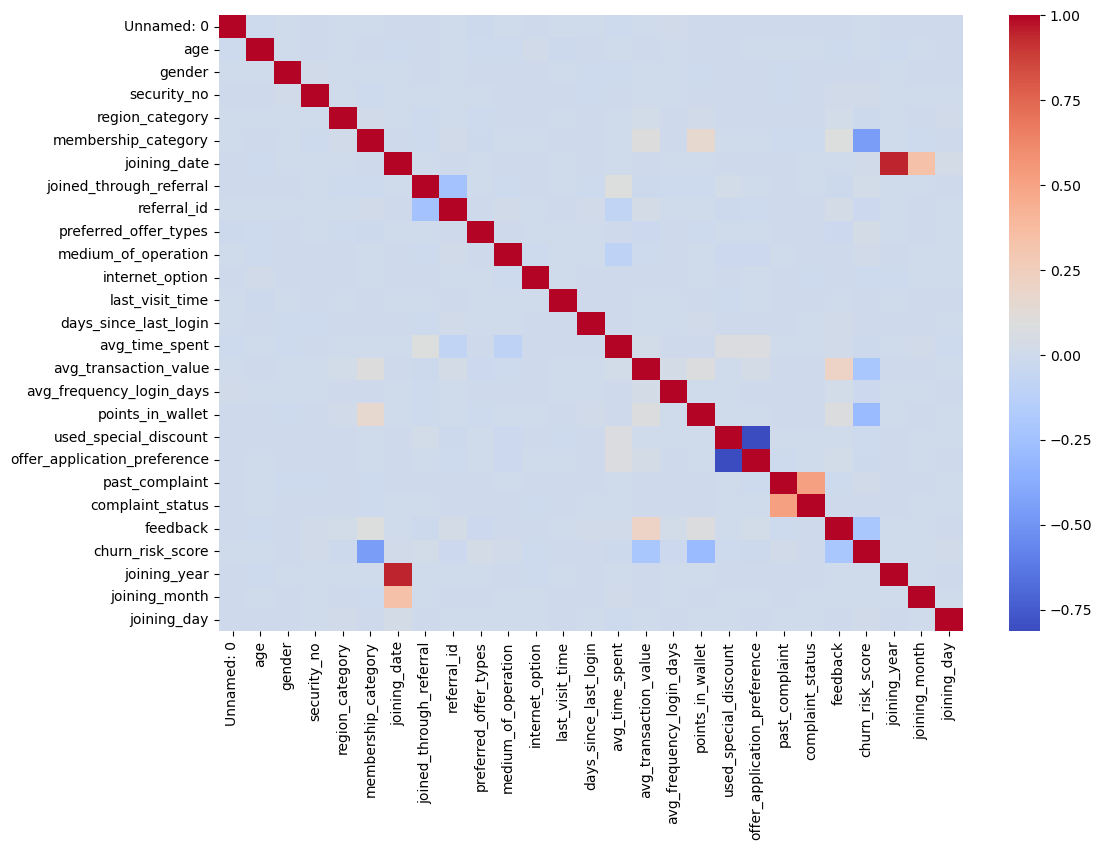

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.show()

In [16]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

Q1 = df[numeric_cols].quantile(0.25)

Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~(
        ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
         (df[numeric_cols] > (Q3 + 1.5 * IQR)))
    ).any(axis=1)
]

In [17]:
df.shape

(25831, 27)

In [18]:
X = df.drop("churn_risk_score", axis=1)

y = df["churn_risk_score"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [20]:
X.dtypes


Unnamed: 0                               int64
age                                      int64
gender                                   int32
security_no                              int32
region_category                          int32
membership_category                      int32
joining_date                    datetime64[ns]
joined_through_referral                  int32
referral_id                              int32
preferred_offer_types                    int32
medium_of_operation                      int32
internet_option                          int32
last_visit_time                          int32
days_since_last_login                    int64
avg_time_spent                         float64
avg_transaction_value                  float64
avg_frequency_login_days                 int32
points_in_wallet                       float64
used_special_discount                    int32
offer_application_preference             int32
past_complaint                           int32
complaint_sta

In [21]:
df["joining_date"] = pd.to_datetime(df["joining_date"])

df["joining_year"] = df["joining_date"].dt.year

df["joining_month"] = df["joining_date"].dt.month

df["joining_day"] = df["joining_date"].dt.day

df.drop("joining_date", axis=1, inplace=True)

In [22]:
X = df.drop("churn_risk_score", axis=1)

y = df["churn_risk_score"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [24]:
X.dtypes

Unnamed: 0                        int64
age                               int64
gender                            int32
security_no                       int32
region_category                   int32
membership_category               int32
joined_through_referral           int32
referral_id                       int32
preferred_offer_types             int32
medium_of_operation               int32
internet_option                   int32
last_visit_time                   int32
days_since_last_login             int64
avg_time_spent                  float64
avg_transaction_value           float64
avg_frequency_login_days          int32
points_in_wallet                float64
used_special_discount             int32
offer_application_preference      int32
past_complaint                    int32
complaint_status                  int32
feedback                          int32
joining_year                      int32
joining_month                     int32
joining_day                       int32


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy =", lr_acc)

Logistic Regression Accuracy = 0.8511708922005032


c:\Users\Geethanjali\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy =", rf_acc)

Random Forest Accuracy = 0.9417456938262048


In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy =", knn_acc)

KNN Accuracy = 0.5419005225469324


In [28]:
print("Logistic Regression =", lr_acc)

print("KNN =", knn_acc)

print("Random Forest =", rf_acc)

Logistic Regression = 0.8511708922005032
KNN = 0.5419005225469324
Random Forest = 0.9417456938262048


In [29]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy =", xgb_acc)

XGBoost Accuracy = 0.9438745887362106


In [30]:
result = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        lr_acc,
        knn_acc,
        rf_acc,
        xgb_acc
    ]
})

print(result)

                 Model  Accuracy
0  Logistic Regression  0.851171
1                  KNN  0.541901
2        Random Forest  0.941746
3              XGBoost  0.943875


In [31]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

pred = xgb.predict(X_test)

print(confusion_matrix(y_test, pred))

print(classification_report(y_test, pred))

[[2109  153]
 [ 137 2768]]
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      2262
           1       0.95      0.95      0.95      2905

    accuracy                           0.94      5167
   macro avg       0.94      0.94      0.94      5167
weighted avg       0.94      0.94      0.94      5167



In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                         Feature  Importance
16              points_in_wallet    0.519068
5            membership_category    0.203386
21                      feedback    0.026335
14         avg_transaction_value    0.013110
18  offer_application_preference    0.012653
17         used_special_discount    0.012429
13                avg_time_spent    0.012228
24                   joining_day    0.011904
7                    referral_id    0.011849
11               last_visit_time    0.011817
3                    security_no    0.011764
20              complaint_status    0.011725
19                past_complaint    0.011587
4                region_category    0.011508
23                 joining_month    0.011475
12         days_since_last_login    0.011462
0                     Unnamed: 0    0.011358
9            medium_of_operation    0.011286
10               internet_option    0.011141
1                            age    0.010879
2                         gender    0.010514
8         

In [33]:
print(importance.head(10))

                         Feature  Importance
16              points_in_wallet    0.519068
5            membership_category    0.203386
21                      feedback    0.026335
14         avg_transaction_value    0.013110
18  offer_application_preference    0.012653
17         used_special_discount    0.012429
13                avg_time_spent    0.012228
24                   joining_day    0.011904
7                    referral_id    0.011849
11               last_visit_time    0.011817


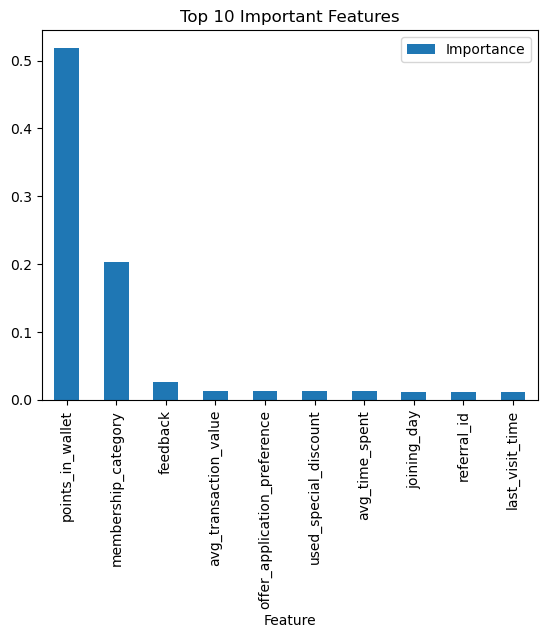

In [34]:
import matplotlib.pyplot as plt

importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 10 Important Features")

plt.show()